In [120]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import csv
from pandas import DataFrame
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, OneHotEncoder, Binarizer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
import wittgenstein as lw
from imodels import GreedyRuleListClassifier

pd.set_option('display.width', 200)  
pd.set_option('display.max_colwidth', 100)

In [2]:
class RIPPERWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, k=2, prune_size=0.33, n_discretize_bins=10,
                 dl_allowance=64, max_rules=None, max_rule_conds=None,
                 max_total_conds=None, random_state=None, verbosity=0):
        self.k = k
        self.prune_size = prune_size
        self.n_discretize_bins = n_discretize_bins
        self.dl_allowance = dl_allowance
        self.max_rules = max_rules
        self.max_rule_conds = max_rule_conds
        self.max_total_conds = max_total_conds
        self.random_state = random_state
        self.verbosity = verbosity

    def fit(self, X, y):
        self.model_ = lw.RIPPER(
            k=self.k,
            prune_size=self.prune_size,
            n_discretize_bins=self.n_discretize_bins,
            dl_allowance=self.dl_allowance,
            max_rules=self.max_rules,
            max_rule_conds=self.max_rule_conds,
            max_total_conds=self.max_total_conds,
            random_state=self.random_state,
            verbosity=self.verbosity,
        )
        y = np.asarray(y).astype(int)
        self.model_.fit(X, y, pos_class=1)
        self.model_.classes_ = np.array([0, 1])
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        preds = self.model_.predict(X)
        return np.array([1 if (p is True or str(p) == '1') else 0 for p in preds])

    def predict_proba(self, X):
        proba = self.model_.predict_proba(X)
        self.model_.classes_ = np.array([0, 1]) 
        return np.asarray(proba, dtype=float)

In [3]:
df = pd.read_csv("responses.csv")
cols = df.columns.to_list()
slices = [0, 2, 19, 31, 63, 73, 76, 133, 140, 150]
sections = ["general music", "music", "movies", "hobbies", "phobias", "health habits", "personality", "spending habits", "demographics"]
dict_cols = {}
for i in range(0, len(sections)):
    dict_cols[sections[i]] = cols[slices[i]:slices[i + 1]]
    
class_cols = dict_cols["music"]
X = df[dict_cols["health habits"] + dict_cols["personality"] + dict_cols["demographics"]]
y_old = df[class_cols]
y = y_old.copy()
for col in class_cols:
    y[col] = y_old[col].map(lambda v: 1 if v > 3 else (0 if v < 3 else np.nan))
    print(y[col].value_counts())
    
print(X.columns.to_list())
print(y.columns.to_list())
df.shape

Dance
1.0    376
0.0    309
Name: count, dtype: int64
Folk
0.0    626
1.0    144
Name: count, dtype: int64
Country
0.0    689
1.0    118
Name: count, dtype: int64
Classical music
0.0    387
1.0    335
Name: count, dtype: int64
Musical
0.0    443
1.0    282
Name: count, dtype: int64
Pop
1.0    532
0.0    215
Name: count, dtype: int64
Rock
1.0    637
0.0    160
Name: count, dtype: int64
Metal or Hardrock
0.0    603
1.0    240
Name: count, dtype: int64
Punk
0.0    546
1.0    236
Name: count, dtype: int64
Hiphop, Rap
0.0    418
1.0    382
Name: count, dtype: int64
Reggae, Ska
0.0    431
1.0    287
Name: count, dtype: int64
Swing, Jazz
0.0    435
1.0    298
Name: count, dtype: int64
Rock n roll
1.0    398
0.0    307
Name: count, dtype: int64
Alternative
0.0    433
1.0    323
Name: count, dtype: int64
Latino
0.0    441
1.0    323
Name: count, dtype: int64
Techno, Trance
0.0    587
1.0    222
Name: count, dtype: int64
Opera
0.0    683
1.0    151
Name: count, dtype: int64
['Smoking', 'Alcohol'

(1010, 150)

In [4]:
print(X.dtypes.value_counts()) 

float64    56
str        11
int64       3
Name: count, dtype: int64


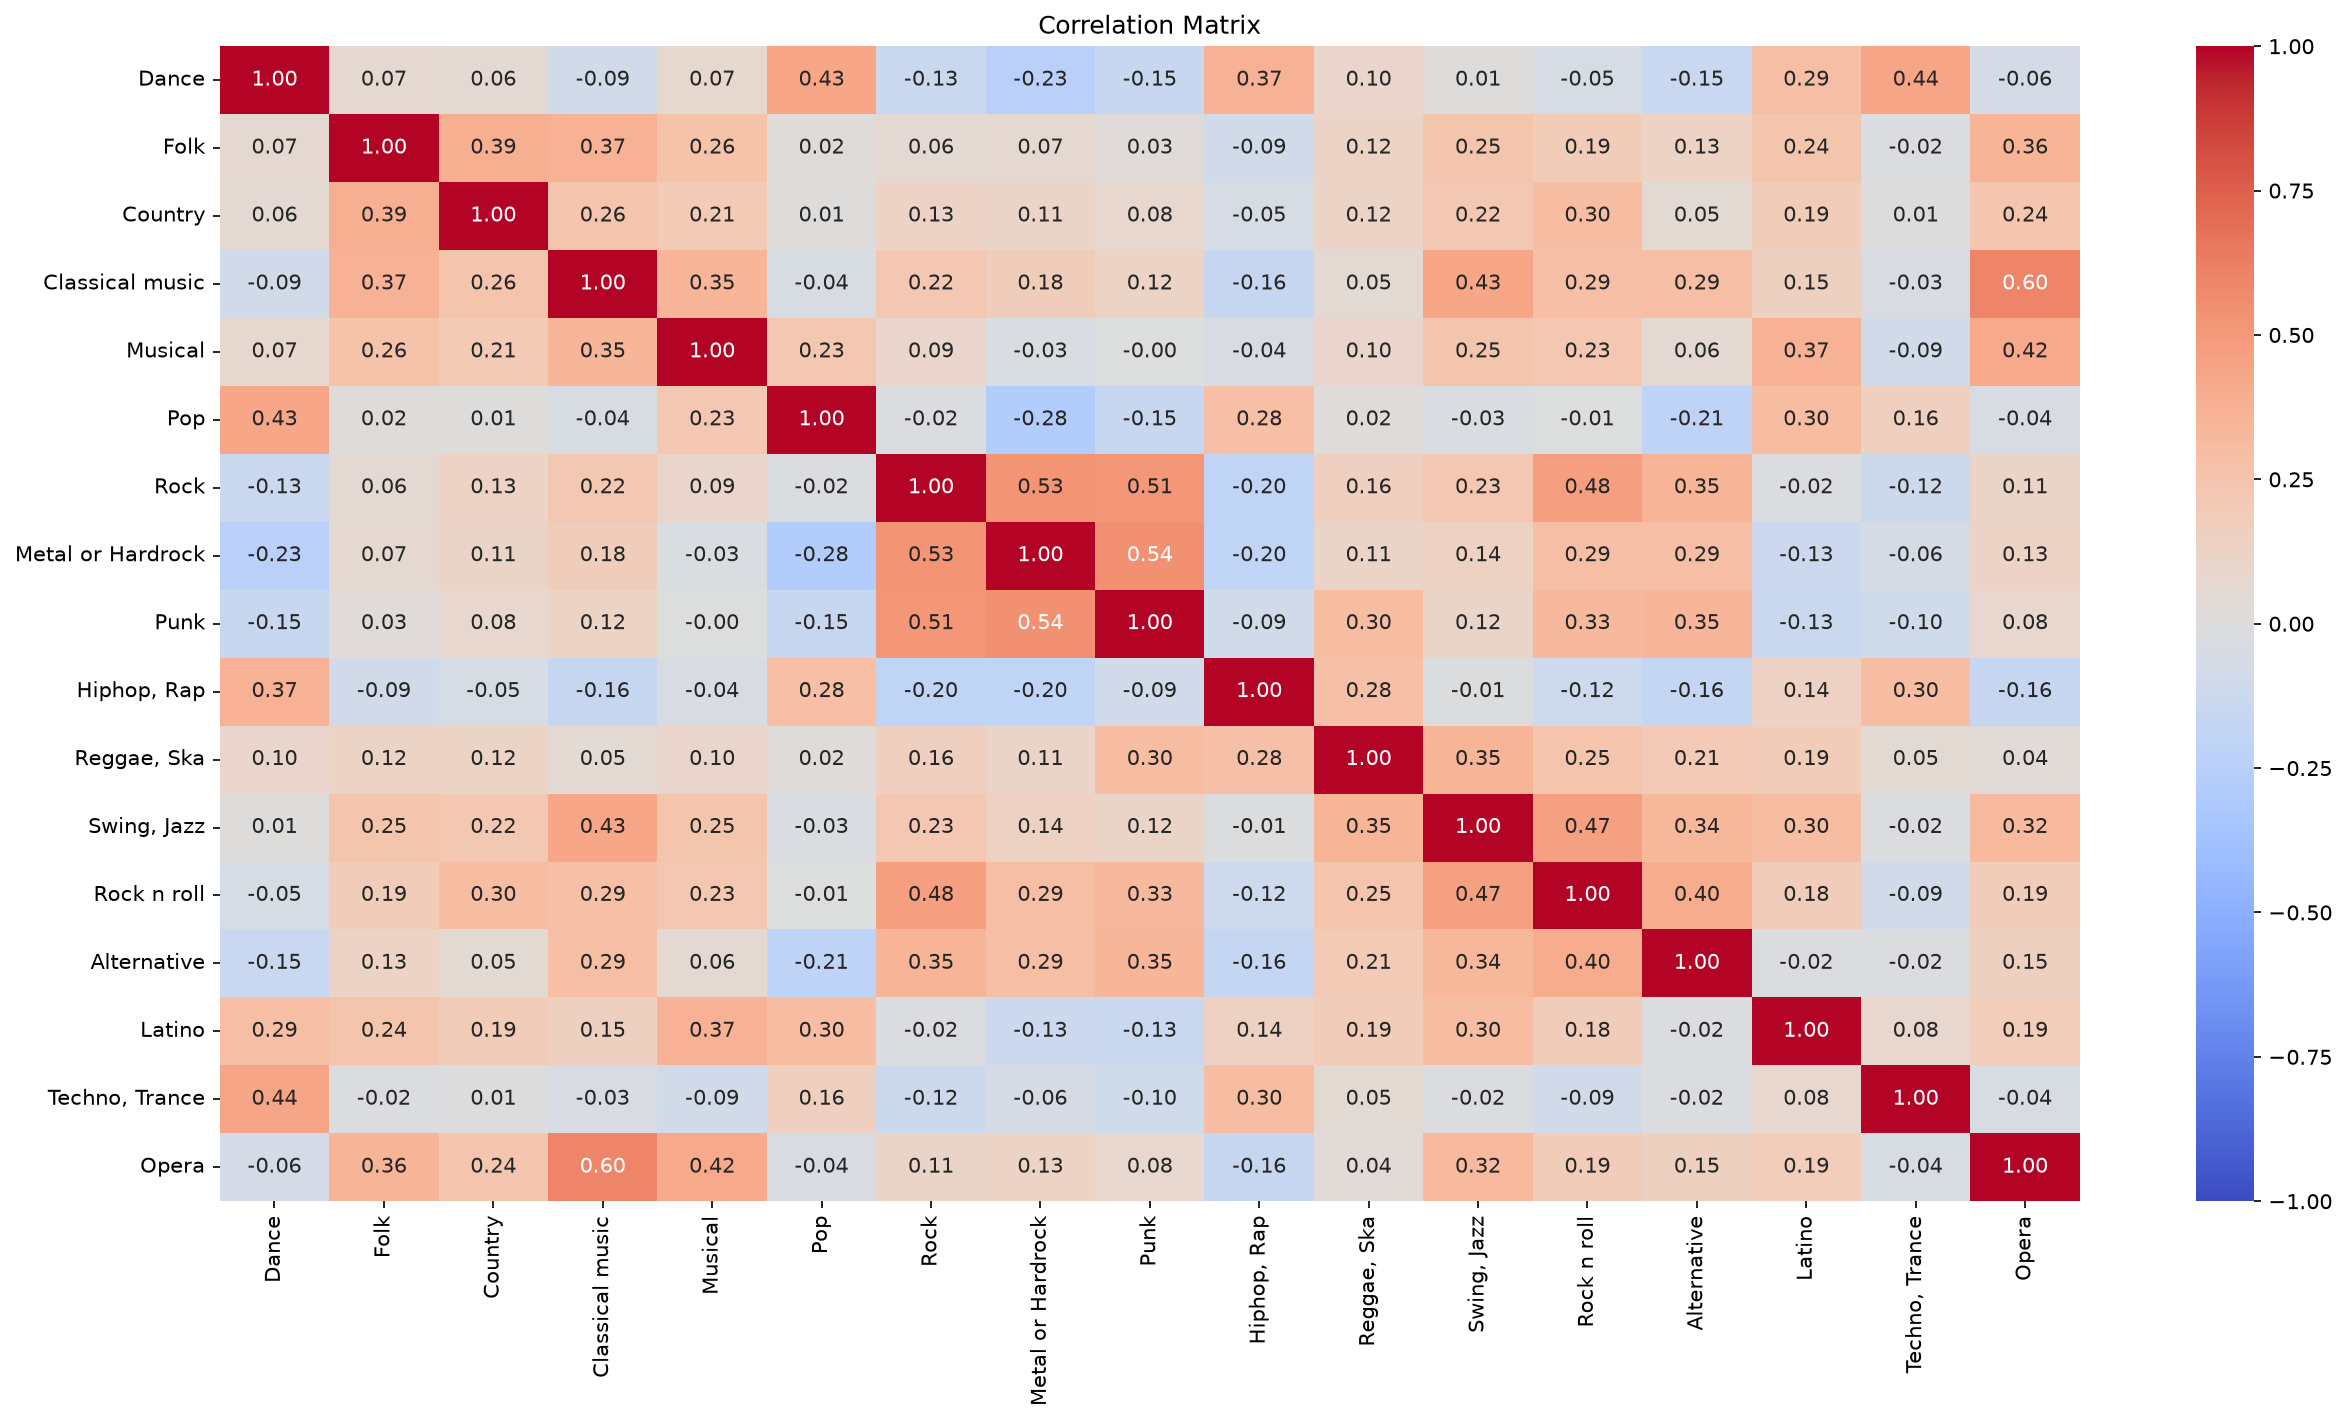

                  col1               col2  correlation
67     Classical music              Opera     0.595905
127  Metal or Hardrock               Punk     0.544016
109               Rock  Metal or Hardrock     0.527118
110               Rock               Punk     0.508821
114               Rock        Rock n roll     0.476323
199        Swing, Jazz        Rock n roll     0.467060
15               Dance     Techno, Trance     0.443044
5                Dance                Pop     0.431962
62     Classical music        Swing, Jazz     0.431371
84             Musical              Opera     0.416599


In [5]:
def most_corr_in_matrix(corr):
    corr_list = (corr
        .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )
    corr_list.columns = ["col1", "col2", "correlation"]
    return corr_list.reindex(
        corr_list["correlation"].abs().sort_values(ascending=False).index
    )

correlation_matrix = df[class_cols].corr()
plt.figure(figsize=(20, 10), dpi=150)
sb.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

print(most_corr_in_matrix(correlation_matrix).head(10))

Column ordering

In [6]:
print(df["Internet usage"].unique().tolist())
print(df["Education"].unique().tolist())
print(df["Alcohol"].unique().tolist())
print(df["Smoking"].unique().tolist())
print(df["Education"].value_counts())

['few hours a day', 'most of the day', 'less than an hour a day', 'no time at all']
['college/bachelor degree', 'secondary school', 'primary school', 'masters degree', 'doctorate degree', 'currently a primary school pupil', nan]
['drink a lot', 'social drinker', 'never', nan]
['never smoked', 'tried smoking', 'former smoker', 'current smoker', nan]
Education
secondary school                    621
college/bachelor degree             212
masters degree                       81
primary school                       80
currently a primary school pupil     10
doctorate degree                      5
Name: count, dtype: int64


In [7]:
ordinal_cols = {
    "Internet usage": ["no time at all", "less than an hour a day", "few hours a day", "most of the day"],
    "Education": ["currently a primary school pupil", "primary school", "secondary school", "college/bachelor degree", "masters degree", "doctorate degree"],
    "Alcohol": ["never", "social drinker", "drink a lot"],
    "Smoking": ["never smoked", "tried smoking", "former smoker", "current smoker"]
}
categorical_cols = ["Lying", "Punctuality"]
binary_cols_dict = {"Gender": "Female", "Left - right handed": "Right handed", "Village - town": "Village", "House - block of flats": "House"}
redundant_cols = ["Only child"]
continuous_cols = ["Age", "Height", "Weight", "Number of siblings"]
for key, value in dict_cols.items():
    print(f"{key}: {value}")

general music: ['Music', 'Slow songs or fast songs']
music: ['Dance', 'Folk', 'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 'Techno, Trance', 'Opera']
movies: ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 'Documentary', 'Western', 'Action']
hobbies: ['History', 'Psychology', 'Politics', 'Mathematics', 'Physics', 'Internet', 'PC', 'Economy Management', 'Biology', 'Chemistry', 'Reading', 'Geography', 'Foreign languages', 'Medicine', 'Law', 'Cars', 'Art exhibitions', 'Religion', 'Countryside, outdoors', 'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 'Active sport', 'Gardening', 'Celebrities', 'Shopping', 'Science and technology', 'Theatre', 'Fun with friends', 'Adrenaline sports', 'Pets']
phobias: ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 'Rats', 'Ageing', 'Dangerous dog

# Preprocessing data

In [8]:
def make_preprocessor(oneHotDropFirst: bool, continuousRemoval: bool, binarized: bool) -> ColumnTransformer:
    # Binary data transformation
    def encode_boolean_cols(df: DataFrame):
        df = df.copy()
        for key, value in binary_cols_dict.items():
            df[value] = df[key].str.contains(value, case=False, na=False).astype(int)
        df = df.drop(columns=binary_cols_dict.keys())
        return df

    # Redundant data removal
    def remove_redundant_data(df: DataFrame):
        df = df.copy()
        if continuousRemoval:
            df = df.drop(columns=redundant_cols + continuous_cols)
        else:
            df["Number of siblings"] = np.where(df["Only child"] == "yes", 0, df["Number of siblings"])
            df["Number of siblings"] = df["Number of siblings"].fillna(0)
            df = df.drop(columns=redundant_cols)
        return df
        
    
    def ordinal_binarizer(values):
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy='most_frequent')),
            ("ordinal", OrdinalEncoder(categories=[values])),
            ("binarize", Binarizer(threshold=len(values) // 2 - 1))
        ])
            
    def ordinal_binarizer_transformers():
        transformers = []
        for ind, (col, values) in enumerate(ordinal_cols.items()):
            transformers.append((f'ordinal{ind}', ordinal_binarizer(values), [col]))
        return transformers
    
    redundant_transformer = FunctionTransformer(remove_redundant_data, feature_names_out=lambda _, __: [] if continuousRemoval else ["Number of siblings"])
    boolean_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('booleanEncoder', FunctionTransformer(encode_boolean_cols, feature_names_out=lambda _, __: list(binary_cols_dict.values())))  
    ]).set_output(transform='pandas')
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=("first" if oneHotDropFirst else None)))
    ])
    if binarized:
        ordinal_transformers = ordinal_binarizer_transformers()
    else:
        transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy='most_frequent')),
            ("ordinal", OrdinalEncoder(categories=list(ordinal_cols.values()), handle_unknown='use_encoded_value', unknown_value=-1))
        ])
        ordinal_transformers = [("ordinal", transformer, list(ordinal_cols.keys()))]
    
    rated_cols_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy='most_frequent'))])
    if binarized:
        rated_cols_transformer.steps.append(("binarize", Binarizer(threshold=3)))

    return ColumnTransformer(
        transformers=[
            ('categorical', categorical_transformer, categorical_cols),
            ('binary', boolean_transformer, list(binary_cols_dict.keys())),
            ('redundant', redundant_transformer, redundant_cols + ["Number of siblings"] + (continuous_cols if continuousRemoval else []))
        ] + ordinal_transformers,
        remainder=rated_cols_transformer
    )

In [9]:
def attribute_vs_class():
    processor = make_preprocessor(True, False, False)
    X_tr_np = processor.fit_transform(X)
    df_temp = pd.DataFrame(X_tr_np, columns=processor.get_feature_names_out())
    df_temp[class_cols] = y
    print(most_corr_in_matrix(df_temp.corr()[class_cols].drop(class_cols)).head(10))

attribute_vs_class()

                          col1               col2  correlation
99              binary__Female             Latino     0.303488
92              binary__Female  Metal or Hardrock    -0.181142
100             binary__Female     Techno, Trance    -0.168189
217           ordinal__Alcohol        Alternative     0.128051
184    ordinal__Internet usage             Latino    -0.125105
200         ordinal__Education        Alternative     0.121861
201         ordinal__Education             Latino     0.117261
254  remainder__Healthy eating              Opera     0.114252
203         ordinal__Education              Opera     0.112929
253  remainder__Healthy eating     Techno, Trance     0.102685


In [10]:
def get_model_name(estimator) -> str:
    while True:
        if hasattr(estimator, "named_steps"):
            estimator = estimator.named_steps.get("model", estimator)
        elif hasattr(estimator, "estimator"):
            estimator = estimator.estimator
        elif hasattr(estimator, "base_estimator"):
            estimator = estimator.base_estimator
        else:
            break
    return type(estimator).__name__

def format_result(grid, score: float, params: dict) -> str:
    score = abs(score)
    name = get_model_name(grid)
    if params:
        param_str = ", ".join(f"{k.split('__')[-1]}={v}" for k, v in params.items())
        return f"{name} ({param_str}) - {score:.4f}"
    return f"{name} - {score:.4f}"

def format_result_metric(grid, score_type: str = "log_loss") -> str:
    idx = grid.cv_results_[f'rank_test_{metric}'].argmin()
    params = grid.cv_results_['params'][idx]
    return format_result(grid, abs(grid.cv_results_[f"mean_test_{score_type}"][idx]), params)

In [11]:
def updateArgs(args: dict[str, list], prefix: str) -> dict[str, list]:
    newArgs = {}
    for key, value in args.items():
        newArgs[f"{prefix}__{key}"] = value
    return newArgs

scoring_metrics = {
    'log_loss': 'neg_log_loss',
    'brier': 'neg_brier_score',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

# Hyperparameter tuning on training set
def hyperParameterModel(model, args: dict[str, list[float]]) -> GridSearchCV:
    grid = GridSearchCV(
        estimator = model,
        param_grid=args,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=37),
        scoring=scoring_metrics,
        refit=False,
        n_jobs=-1,
        error_score='raise'
    )
    return grid

def getModel(model_type: dict) -> GridSearchCV:
    model = model_type["model"]() if "uncalibrated" in model_type else CalibratedClassifierCV(model_type["model"](), cv=5, method='sigmoid')
    args = updateArgs(model_type["args"], "estimator")
    steps = []
    steps.append(("preprocess", make_preprocessor(model_type["drop_first"], model_type["categorical"], model_type["binarized"])))
    if model_type["standardized"]:
        steps.append(("standardize", StandardScaler()))
    steps.append(("model", model))
    args = updateArgs(args, "model") 
    return hyperParameterModel(Pipeline(steps), args)

In [12]:
def train_test(X: DataFrame, y: DataFrame):
    y_split = y.copy()
    for col in class_cols:
        most_frequent = y_split[col].mode(dropna=True)[0]
        y_split[col] = y_split[col].fillna(most_frequent)
    ms = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=37)
    train_index, test_index = next(ms.split(X, y_split))
    return X.iloc[train_index], X.iloc[test_index], y.iloc[train_index], y.iloc[test_index]

X_tr, X_te, y_tr, y_te = train_test(X, y)
X_train, y_train = {}, {}
for col in class_cols:
    train_mask = y_tr[col].notna()
    X_train[col] = X_tr.loc[train_mask]
    y_train[col]= y_tr[col].loc[train_mask]

In [103]:
# model_selection = [
#     {
#         "model": lambda: CategoricalNB(min_categories=6),
#         "args": {
#             "alpha": [0.5, 1.0, 2.0]
#         },
#         "standardized": False,
#         "categorical": True,
#         "drop_first": True,
#         "binarized": False
#     },
#     {
#         "model": lambda: GaussianNB(),
#         "args": {},
#         "standardized": False,
#         "categorical": False,
#         "drop_first": True,
#         "binarized": False
#     },
#     {
#         "model": lambda: BernoulliNB(),
#         "args": {
#             "alpha": [0.5, 1.0, 2.0],
#             "binarize": [0.3, 0.5, 0.7]
#         },
#         "standardized": False,
#         "categorical": True,
#         "drop_first": True,
#         "binarized": True
#     },
#     {
#         "model": lambda: LogisticRegression(random_state=37),
#         "args": {},
#         "standardized": True,
#         "categorical": False,
#         "drop_first": True,
#         "binarized": False
#     },
#     {
#         "model": lambda: SVC(random_state=37, C=0.1),
#         "args": {
#             "kernel": ["linear", "rbf", "poly", "sigmoid"],
#             "gamma": ["scale", "auto"]
#         },
#         "standardized": True,
#         "categorical": False,
#         "drop_first": True,
#         "binarized": False
#     },
#     {
#         "model": lambda: XGBClassifier(eval_metric="logloss", n_jobs=1),
#         "args": {
#             "max_depth": [0, 3, 4, 5, 6, 8],
#             "n_estimators": [50, 100, 200],
#             "learning_rate": [0.01, 0.05, 0.1, 0.2]
#         },
#         "standardized": False,
#         "categorical": False,
#         "drop_first": False,
#         "binarized": False
#     },
#     {
#         "model": lambda: DecisionTreeClassifier(random_state=37),
#         "args": {
#             "max_depth": [3, 4, 5, 6, 10, None],
#             "min_samples_leaf": [2, 3, 4]
#         },
#         "standardized": False,
#         "categorical": False,
#         "drop_first": False,
#         "binarized": False
#     },
#     {
#         "model": lambda: KNeighborsClassifier(),
#         "args": {
#             "n_neighbors": [1, 3, 5, 7, 9]
#         },
#         "standardized": True,
#         "categorical": False,
#         "drop_first": False,
#         "binarized": False
#     },
#     {
#         "model": lambda: RIPPERWrapper(random_state=37),
#         "args": {
#             "max_rule_conds": [2, 3, 5, 10]
#         },
#         "standardized": False,
#         "categorical": False,
#         "drop_first": False,
#         "binarized": False
#     },
#     {
#         "model": lambda: GreedyRuleListClassifier(),
#         "args": {
#             "max_depth": [3, 5, 10]
#         },
#         "standardized": False,
#         "categorical": False,
#         "drop_first": False,
#         "binarized": False
#     },
# ]

model_selection = [
    # {
    #     "model": lambda: LogisticRegression(random_state=37),
    #     "args": {},
    #     "standardized": True,
    #     "categorical": False,
    #     "drop_first": True,
    #     "binarized": False
    # },
    {
        "model": lambda: DecisionTreeClassifier(random_state=37),
        "args": {
            "max_depth": [1, 3, 4, 5, 6, 10, None],
            "min_samples_leaf": [1, 2, 3, 4]
        },
        "standardized": False,
        "categorical": False,
        "drop_first": False,
        "binarized": False
    },
    # {
    #     "model": lambda: RIPPERWrapper(random_state=37, prune_size=0.1, dl_allowance=32),
    #     "args": {
    #         "max_rule_conds": [2, 3, 5, 10],
    #         "k": [2, 3, 4]
    #     },
    #     "standardized": False,
    #     "categorical": False,
    #     "drop_first": False,
    #     "binarized": False
    # },
    # {
    #     "model": lambda: GreedyRuleListClassifier(),
    #     "args": {
    #         "max_depth": [3, 5, 10]
    #     },
    #     "standardized": False,
    #     "categorical": False,
    #     "drop_first": False,
    #     "binarized": False
    # },
]

dummy_model_selection = {
    "model": lambda: DummyClassifier(strategy="prior", random_state=37),
    "args": {},
    "standardized": False,
    "categorical": False,
    "drop_first": False,
    "binarized": False,
    "uncalibrated": True
}

In [104]:
import warnings
from scipy.optimize import OptimizeWarning
warnings.filterwarnings("ignore", category=OptimizeWarning, message="Unknown solver options: iprint")

import sklearn
sklearn.set_config(transform_output="pandas")

all_models = {}
X_columns_per_genre = {}

for col in class_cols:
    model_results = []
    
    print(f"{col}:", end=" ")
    for selection in model_selection:
        try:
            model = getModel(selection)
            model.fit(X_train[col], y_train[col])
            model_results.append(model)
            print(get_model_name(model_results[-1]), end=" ")
        except Exception as e:
            print(f"An error occurred: {e}")
    
    all_models[col] = model_results
    print()

Dance: DecisionTreeClassifier 
Folk: DecisionTreeClassifier 
Country: DecisionTreeClassifier 
Classical music: DecisionTreeClassifier 
Musical: DecisionTreeClassifier 
Pop: DecisionTreeClassifier 
Rock: DecisionTreeClassifier 
Metal or Hardrock: DecisionTreeClassifier 
Punk: DecisionTreeClassifier 
Hiphop, Rap: DecisionTreeClassifier 
Reggae, Ska: DecisionTreeClassifier 
Swing, Jazz: DecisionTreeClassifier 
Rock n roll: DecisionTreeClassifier 
Alternative: DecisionTreeClassifier 
Latino: DecisionTreeClassifier 
Techno, Trance: DecisionTreeClassifier 
Opera: DecisionTreeClassifier 


In [105]:
# Dummy train
dummy_models = {}

for col in class_cols:
    dummy_model = getModel(dummy_model_selection)
    dummy_model.fit(X_train[col], y_train[col])
    dummy_models[col] = dummy_model

In [123]:
metrics = list(scoring_metrics)
def train_best_model(metric: str) -> dict:
    print(f"{metric}: ")
    best_models = {}
    for col in class_cols:
        # print(f"{col}: ")
        best_model = None
        best_score = 0
        best_scores = {}
        best_params = None
        for grid in all_models[col]:
            ranking = grid.cv_results_[f'rank_test_{metric}']
            best_index = ranking.argmin()
            best_cv_score = grid.cv_results_[f'mean_test_{metric}'][best_index]
            all_scores = {}
            for m in metrics:
                all_scores[m] = float(grid.cv_results_[f'mean_test_{m}'][best_index])
            # print(f"{get_model_name(grid)}: {best_cv_score:.4f}")
            
            if best_model is None or best_cv_score > best_score:
                best_score = best_cv_score
                best_scores = all_scores
                best_params = grid.cv_results_['params'][best_index]
                best_model = clone(grid.estimator).set_params(**best_params)
        # print(f"Best model: {get_model_name(best_model)}: {best_score:.4f}")
        best_model.fit(X_train[col], y_train[col])
        best_models[col] = (best_model, best_score, best_scores, best_params)
    return best_models

def get_base_model(model):
    return model.named_steps["model"].calibrated_classifiers_[0].estimator

def get_feature_names(model):
    feature_names = model.named_steps["preprocess"].get_feature_names_out()
    feature_names = [x.split("__")[-1] for x in feature_names]
    return feature_names

best_models_score = {}
for metric in [metrics[0]]:
    best_models_score[metric] = train_best_model(metric)

log_loss: 


In [107]:
metric = metrics[0]
best_model_score = best_models_score[metric]
best_model_genre = {}
for k, v in best_model_score.items():
    best_model_genre[k] = v[0]
    print(f"{k}: {get_model_name(v[0])}")

Dance: DecisionTreeClassifier
Folk: DecisionTreeClassifier
Country: DecisionTreeClassifier
Classical music: DecisionTreeClassifier
Musical: DecisionTreeClassifier
Pop: DecisionTreeClassifier
Rock: DecisionTreeClassifier
Metal or Hardrock: DecisionTreeClassifier
Punk: DecisionTreeClassifier
Hiphop, Rap: DecisionTreeClassifier
Reggae, Ska: DecisionTreeClassifier
Swing, Jazz: DecisionTreeClassifier
Rock n roll: DecisionTreeClassifier
Alternative: DecisionTreeClassifier
Latino: DecisionTreeClassifier
Techno, Trance: DecisionTreeClassifier
Opera: DecisionTreeClassifier


In [111]:
for col, (model, score, all_scores, params) in best_model_score.items():
    line = format_result(model, score, params)

    dummy_part = format_result_metric(dummy_models[col], metric)
    print(f"{col}: {line}, {dummy_part}")

Dance: DecisionTreeClassifier (max_depth=5, min_samples_leaf=2) - 0.6789, DummyClassifier - 0.6878
Folk: DecisionTreeClassifier (max_depth=4, min_samples_leaf=3) - 0.4765, DummyClassifier - 0.4827
Country: DecisionTreeClassifier (max_depth=3, min_samples_leaf=2) - 0.4135, DummyClassifier - 0.4153
Classical music: DecisionTreeClassifier (max_depth=6, min_samples_leaf=4) - 0.6857, DummyClassifier - 0.6915
Musical: DecisionTreeClassifier (max_depth=1, min_samples_leaf=1) - 0.6377, DummyClassifier - 0.6686
Pop: DecisionTreeClassifier (max_depth=None, min_samples_leaf=4) - 0.5983, DummyClassifier - 0.6029
Rock: DecisionTreeClassifier (max_depth=3, min_samples_leaf=4) - 0.4978, DummyClassifier - 0.5004
Metal or Hardrock: DecisionTreeClassifier (max_depth=None, min_samples_leaf=4) - 0.5947, DummyClassifier - 0.5975
Punk: DecisionTreeClassifier (max_depth=6, min_samples_leaf=2) - 0.6138, DummyClassifier - 0.6157
Hiphop, Rap: DecisionTreeClassifier (max_depth=1, min_samples_leaf=1) - 0.6781, Du

In [112]:
y_proba = pd.DataFrame(index=y_te.index)
for col, (model, _, _, _) in best_model_score.items():
    p1 = model.predict_proba(X_te)[:, 1]
    y_proba[col] = p1

In [113]:
def top_per_row(row, n=3):
    top = row.sort_values(ascending=False).head(n)
    return list(zip(top.index, top.values))

for ind, (idx, row) in enumerate(y_proba.iterrows()):
    if ind >= 3:
        break
    topn = top_per_row(row, 5)
    print(f"Row {idx}:")
    for col, val in topn:
        print(f"  {col}: {val:.2%}")
    print()

Row 12:
  Rock: 79.21%
  Pop: 71.22%
  Dance: 56.70%
  Latino: 54.63%
  Rock n roll: 52.60%

Row 13:
  Rock: 81.47%
  Pop: 70.94%
  Hiphop, Rap: 58.74%
  Dance: 56.54%
  Latino: 54.63%

Row 15:
  Rock: 80.11%
  Pop: 70.18%
  Rock n roll: 56.71%
  Classical music: 48.79%
  Dance: 46.09%



In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

def get_thresholds():
    best_thresholds = np.zeros(y_tr.shape[1])
    possible_thresholds = np.array(range(1, 12))
    for idx, (col, (model, score, _, _)) in enumerate(best_models_score[metric].items()):
        cv = all_models[col][0].cv
        proba = cross_val_predict(
            model, 
            X_train[col], 
            y_train[col], 
            cv=cv,
            method='predict_proba'
        )[:, 1]
        
        best_t, best_f1 = 0.5, 0.0
        for t in possible_thresholds:
            t = t / 20
            preds = (proba >= t).astype(int)
            score = f1_score(y_train[col], preds, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_t = t
                
        best_thresholds[idx] = best_t
    return best_thresholds

thresholds = get_thresholds()
print(thresholds)

In [122]:
def tabular_model_vs_dummy_scores():
    best_model_score = best_models_score[metrics[0]]
    models = {}
    for col, (model, score, _, _) in best_model_score.items():
        models[col] = (get_model_name(model), float(score), float(dummy_models[col].cv_results_[f"mean_test_{metric}"][0]))
        # print(models[col])
    
    with open("model_vs_dummy.csv", "w", newline="") as f:
        writer = csv.writer(f)
        # Write Header
        writer.writerow(["GENRE", "MODEL", "LOG LOSS", "DUMMY LOG LOSS", "RELATIVE_IMPROVEMENT", "POSITIVE CLASS"])
        
        # Write Rows (Ignoring the 3rd tuple element)
        for col, (model_name, score, dummy_score) in models.items():
            positive_class = y_train[col].mean() * 100
            rel = (abs(dummy_score) - abs(score)) / abs(dummy_score) * 100
            writer.writerow([col, model_name, f"{abs(score):.4f}", f"{abs(dummy_score):.4f}", f"{rel:.2f}%", f"{positive_class:.2f}%"])

def tabular_model_selection():
    best_model_score = best_models_score[metrics[0]]
    best_models = {}
    dummy_models = {}
    for col, (model, score, all_scores, params) in best_model_score.items():
        # print(f"{col}, {get_model_name(model)}: {all_scores}")
        params_str = {}
        for key, value in params.items():
            params_str[key.split("__")[-1]] = value
        best_models[col] = (get_model_name(model), params_str, score, all_scores[metrics[2]])
    
    with open("data_export.csv", "w", newline="") as f:
        writer = csv.writer(f)
        # Write Header
        writer.writerow(["GENRE", "MODEL", "PARAMETERS", "LOG LOSS", "ROC AUC"])
        
        # Write Rows (Ignoring the 3rd tuple element)
        for col, (model_name, params, score, roc_auc) in best_models.items():
            param_str = str(params).replace("'", "").replace("{", "").replace("}", "")
            writer.writerow([col, model_name, param_str, f"{abs(score):.4f}", f"{roc_auc:.4f}"])

def get_tabular_probabilities():
    with open("data_probabilities.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["GENRE", "THRESHOLD"])

        for col, threshold in zip(class_cols, thresholds):
            writer.writerow([col, f"{int(threshold * 100)}%"])

models = ["Final model", "Dummy model", "Random model"]

def tabular_model_eval():
    with open("model_eval.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["MODEL", "PRECISION@3", "RECALL@3", "F1@3", "PRECISION@5", "RECALL@5", "F1@5"])
        for ind in range(1, 4):
            metrics3 = get_metrics(3, ind)
            metrics5 = get_metrics(5, ind)
            writer.writerow([models[ind - 1], metrics3["precision@3"], metrics3["recall@3"], metrics3["f1@3"],
                             metrics5["precision@5"], metrics5["recall@5"], metrics5["f1@5"]])
            
def get_tabular_ripper_rules():
    with open("ripper_rules.csv", "w", newline="", encoding="utf8") as f:
        writer = csv.writer(f)
        writer.writerow(["GENRE", "RULES"])
        for col, model in best_model_genre.items():
            feature_names = get_feature_names(model)
            ripper = get_base_model(model).model_
            rules = ripper.ruleset_.rules
            rule_str = []
            for rule in rules:
                conds = []
                for cond in rule.conds:
                    try:
                        val = int(cond.val) if cond.val == int(cond.val) else cond.val
                        conds.append(f"{feature_names[cond.feature]}={val}")
                    except Exception:
                        conds.append(f"{feature_names[cond.feature]}{cond.val}")
                        
                    
                rule_str.append(f"({" ∧ ".join(conds)})")
            writer.writerow([col, " V ".join(rule_str)])

def get_tabular_greedy_rules():
    with open("greedy_rules.csv", "w", newline="", encoding="utf8") as f:
        writer = csv.writer(f)
        writer.writerow(["GENRE", "RULES"])
        for col, model in best_model_genre.items():
            greedy = get_base_model(model)
            # print(greedy)
            conds = []
            for rule in greedy.rules_:
                cond = ""
                if "col" not in rule or rule["col"] == -2:
                    cond = "ELSE"
                    proba = f"{rule["val"] * 100:.2f}%"
                else:
                    col_name = str(rule["col"]).split("__")[-1]
                    sign = '<=' if rule['flip'] else '>'
                    cutoff = rule["cutoff"]
                    cond = f"{col_name} {sign} {cutoff}"
                    proba = f"{rule["val_right"] * 100:.2f}%"

                
                conds.append(f"{cond} ({proba})")
            writer.writerow([col, " V ".join(conds)])
    
# tabular_model_selection()
# tabular_model_vs_dummy_scores()
# tabular_model_eval()
# get_tabular_probabilities()
# get_tabular_ripper_rules()
# get_tabular_greedy_rules()

In [ ]:
s = None
def get_metrics(k: int, type: int):
    global s
    indices_sum = np.zeros(len(y_te.columns))
    prob_vals = y_proba.values
    prob_vals = np.where(prob_vals >= thresholds, prob_vals, -np.inf)
    true_vals = y_te.values
    counts = (y_tr == 1).sum(axis=0).to_numpy()
    
    n_samples, n_cols = prob_vals.shape
    precisions = []
    recalls = []
    f1 = []
    
    desc_idx = np.argsort(counts)[-k:]
    rand_idx = np.random.choice(n_cols, size=k, replace=False)
    top_k_indices = np.argsort(prob_vals, axis=1)[:, -k:]
    
    for i in range(n_samples):
        indices = top_k_indices[i] if type == 1 else (desc_idx if type == 2 else rand_idx)
        for idx in indices:
            indices_sum[idx] += 1
        top_k_labels = true_vals[i, indices]
        tp_count = np.nansum(top_k_labels == 1)
        total_positives = np.nansum(true_vals[i] == 1)
        if total_positives == 0:
            continue
        
        precision = tp_count / k
        recall = tp_count / total_positives
        precisions.append(precision) 
        recalls.append(recall)
        f1.append(2 * precision * recall / (precision + recall) if recall + precision != 0 else 0)
    s = indices_sum
    return {
        f"precision@{k}": f"{(float(np.mean(precisions))*100):.2f}%" if precisions else "0%",
        f"recall@{k}": f"{(float(np.mean(recalls))*100):.2f}%" if recalls else "0%",
        f"f1@{k}": f"{(float(np.mean(f1))*100):.2f}%" if f1 else "0%"
    }

print(get_metrics(5, 1))
print(s)
print(get_metrics(3, 1))
print(s)

{'precision@5': '47.47%', 'recall@5': '49.49%', 'f1@5': '44.65%'}
[178.   0.   0.  44.  13. 202. 202.   0.   0.  70.   0.   0. 186.   5.
 110.   0.   0.]
{'precision@3': '53.70%', 'recall@3': '35.02%', 'f1@3': '38.87%'}
[ 70.   0.   0.   0.   0. 202. 202.   0.   0.  51.   0.   0.  71.   0.
  10.   0.   0.]


In [ ]:
# Log loss
# 3: {'precision@3': 0.5606060606060606, 'recall@3': 0.36921711681069974, 'f1@3': 0.4085013331225452}
# 5: {'precision@5': 0.5080808080808081, 'recall@5': 0.531771812230814, 'f1@5': 0.47929309994818015}

# Most popular
# 3: {'precision@3': 0.5420875420875421, 'recall@3': 0.3327776303712132, 'f1@3': 0.38212581470157225}
# 5: {'precision@5': 0.47474747474747475, 'recall@5': 0.5051305242258897, 'f1@5': 0.4492356854210687}

# Random
# 3: {'precision@3': 0.3114478114478114, 'recall@3': 0.1793442511802583, 'f1@3': 0.21431409499591317}
# 5: {'precision@5': 0.2222222222222222, 'recall@5': 0.18687341657484255, 'f1@5': 0.19134702525968122}

# Results for different metric selected for best model comparison
# 3: {'precision@3': 0.5454545454545454, 'recall@3': 0.34677024550019203, 'f1@3': 0.392131647813466}
# 5: {'precision@5': 0.5040404040404041, 'recall@5': 0.5207111136701155, 'f1@5': 0.4734138501295364}

# 3: {'precision@3': 0.5404040404040404, 'recall@3': 0.3466179286812085, 'f1@3': 0.3898556409920046}
# 5: {'precision@5': 0.4919191919191919, 'recall@5': 0.5096120275710294, 'f1@5': 0.46252734606121415}

# 3: {'precision@3': 0.5656565656565656, 'recall@3': 0.3713117814053643, 'f1@3': 0.41343325585749824}
# 5: {'precision@5': 0.48787878787878786, 'recall@5': 0.5107081256368243, 'f1@5': 0.4603229526135052}

In [91]:
# Tree rules extraction
def extract_rules(model, col) -> list[tuple[float, int, str]]:
    tree_model = get_base_model(model)
    tree = tree_model.tree_
    rules = []
    feature_names = model.named_steps["preprocess"].get_feature_names_out()
    feature_names = [x.split("__")[-1] for x in feature_names]
    
    def dfs(u, conds):
        l = tree.children_left[u]
        r = tree.children_right[u]
        samples = tree.n_node_samples[u]
        counts = tree.value[u]
        gini = tree.impurity[u]
        if l == r:
            # if gini == 0:
            rules.append((f"{float(gini):.2f}", int(samples), y_train[col].shape[0], float(counts[0][1]), col, " AND ".join(conds)))
            return
        feature = feature_names[tree.feature[u]]
        threshold = tree.threshold[u]

        dfs(l, conds + [f"{feature} <= {threshold:.2f}"])
        dfs(r, conds + [f"{feature} > {threshold:.2f}"])
    
    dfs(0, [])
    return rules

def print_rules():
    rules = []
    for col in class_cols:  
        rules = rules + extract_rules(best_model_genre[col], col)
        
    def format_rule(rule):
        s = "likes" if rule[3] > 0.5 else "dislikes"
        return f"{rule[-2]}: {rule[-1]} => {s} ({rule[1]}/{rule[2]} instances covered)"

    rules.sort(key=lambda x: (x[0], -x[1]))
    cnt = 0
    for rule in rules:
        cnt += 1
        if cnt > 10:
            break
        print(format_rule(rule))
        # print(rule)
# print_rules()

In [92]:
# Ispis stabla
def print_trees():
    for col, model in best_model_genre.items():
        feature_names = get_feature_names(model)
        print(col)
        plt.figure(figsize=(20, 10), dpi=150)
        plot_tree(
            get_base_model(model),
            feature_names=feature_names,
            class_names=["0", "1"],
            filled=True,
            rounded=True,
            fontsize=8,
            max_depth=4,
            precision=2
        )
        plt.tight_layout()
        plt.show()
    
# print_trees()